# Sample Superstore - Data Analysis

This notebook performs exploratory data analysis (EDA) on the Sample Superstore dataset. The outputs and visualizations have been professionally enhanced for better readability and a cleaner presentation while maintaining the original concepts.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configure enhanced visualizations and ignore warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Data Loading and Overview
Loading the dataset from the CSV file and inspecting its basic structure.

In [2]:
try:
    df = pd.read_csv('samplesuperstore.csv')
    display(df.head())
except FileNotFoundError:
    print('Dataset not found. Please ensure samplesuperstore.csv is in the /content/ directory.')

Dataset not found. Please ensure samplesuperstore.csv is in the /content/ directory.


In [6]:
if 'df' not in globals():
    try:
        df = pd.read_csv('samplesuperstore.csv')
    except FileNotFoundError:
        raise FileNotFoundError("samplesuperstore.csv not found. Run the data loading cell with the correct path.")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  object 
 6   Customer Name   10194 non-null  object 
 7   Segment         10194 non-null  object 
 8   Country/Region  10194 non-null  object 
 9   City            10194 non-null  object 
 10  State/Province  10194 non-null  object 
 11  Postal Code     10194 non-null  object 
 12  Region          10194 non-null  object 
 13  Product ID      10194 non-null  object 
 14  Category        10194 non-null  object 
 15  Sub-Category    10194 non-null  object 
 16  Product Name    10194 non-null  object 
 17  Sales           10194 non-null 

Generate summary statistics for the numerical columns. We use pandas styling to improve the table layout.

In [7]:
display(df.describe().style.format('{:.2f}').background_gradient(cmap='Blues'))

,Row ID,Sales,Quantity,Discount,Profit
count,10194.00,10194.00,10194.00,10194.00,10194.00
mean,5097.50,228.23,3.79,0.16,28.67
std,2942.90,619.91,2.23,0.21,232.47
min,1.00,0.44,1.00,0.00,-6599.98
25%,2549.25,17.22,2.00,0.00,1.76
50%,5097.50,53.91,3.00,0.20,8.69
75%,7645.75,209.50,5.00,0.20,29.30
max,10194.00,22638.48,14.00,0.80,8399.98


Check for any missing values across all columns:

In [8]:
missing_values = df.isnull().sum().to_frame(name='Missing Count')
display(missing_values[missing_values['Missing Count'] > 0] if missing_values['Missing Count'].sum() > 0 else 'No missing values found.')

'No missing values found.'

## 2. Data Cleaning & Feature Engineering
Convert the raw date strings into standard pandas datetime objects. This allows us to calculate metrics like `Delivery Days`.

In [9]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Calculate delivery time in days
df['Delivery Days'] = (df['Ship Date'] - df['Order Date']).dt.days

# Preview the newly created features
display(df[['Order Date', 'Ship Date', 'Delivery Days']].head())

,Order Date,Ship Date,Delivery Days
0,2023-01-03,2023-01-07,4
1,2023-01-04,2023-01-08,4
2,2023-01-04,2023-01-08,4
3,2023-01-04,2023-01-08,4
4,2023-01-05,2023-01-12,7


## 3. Exploratory Data Analysis (EDA)
Aggregating the total sales by category and plotting the results with a polished, presentation-ready chart.

In [10]:
# Aggregate and sort sales data
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False).reset_index()

# Display as a styled table
display(category_sales.style.format({'Sales': '${:,.2f}'}).bar(subset=['Sales'], color='#5fba7d'))

,Category,Sales
0,Technology,"$839,893.28"
1,Furniture,"$754,747.76"
2,Office Supplies,"$731,893.31"


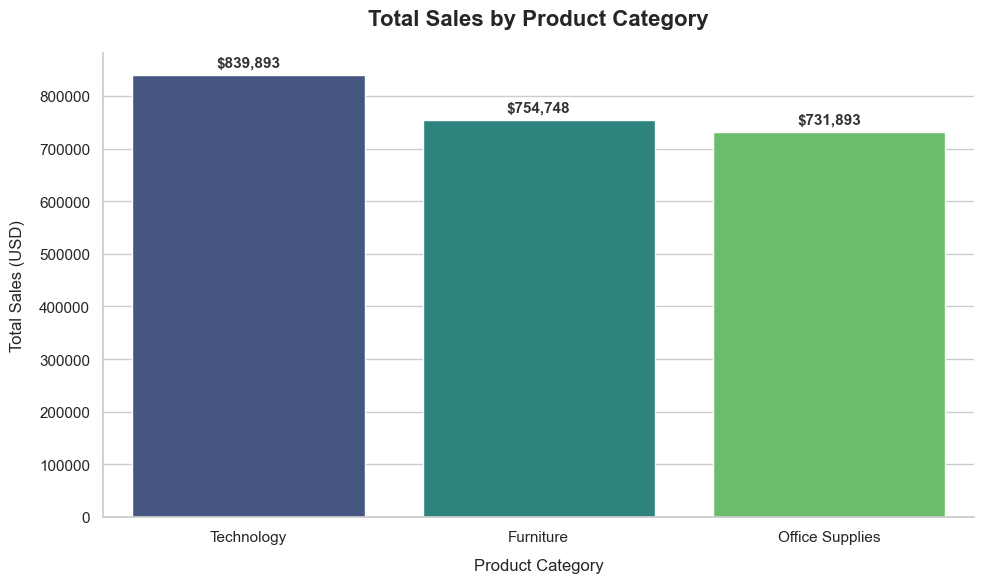

In [11]:
plt.figure(figsize=(10, 6))

# Create a polished barplot
ax = sns.barplot(x='Category', y='Sales', data=category_sales, palette='viridis')

# Add dynamic data labels to the top of each bar
for p in ax.patches:
    ax.annotate(f'${p.get_height():,.0f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=11, 
                fontweight='bold',
                color='#333333')

# Enhance title and axis labels
plt.title('Total Sales by Product Category', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Product Category', fontsize=12, labelpad=10)
plt.ylabel('Total Sales (USD)', fontsize=12, labelpad=10)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# Remove top and right borders for a modern, clean look
sns.despine()

plt.tight_layout()
plt.show()